In [7]:
#from data import load_data
%load_ext autoreload
%autoreload 2
import numpy as np
import json
import os
import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [57]:
embeddings = np.load('logs/2026_4_30/4/embeddings.npy')
print(embeddings.shape)

(19389, 10)


Text(0.5, 1.0, 'Training loss')

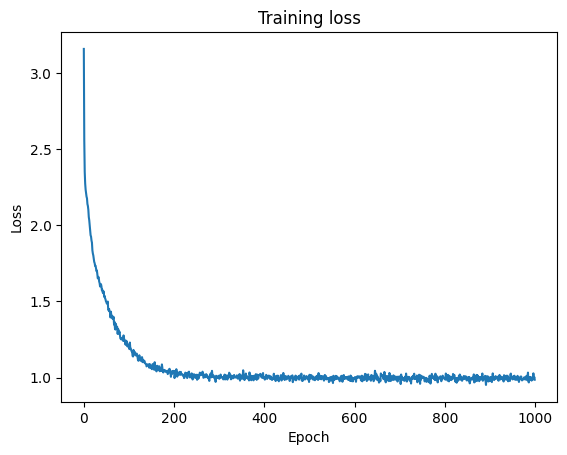

In [59]:
with open(os.path.join("logs/2026_4_30/4", 'metrics.json'), 'r') as f:
    results = json.load(f)

plt.plot(results['train_losses'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training loss')

Text(0, 0.5, 'MAP')

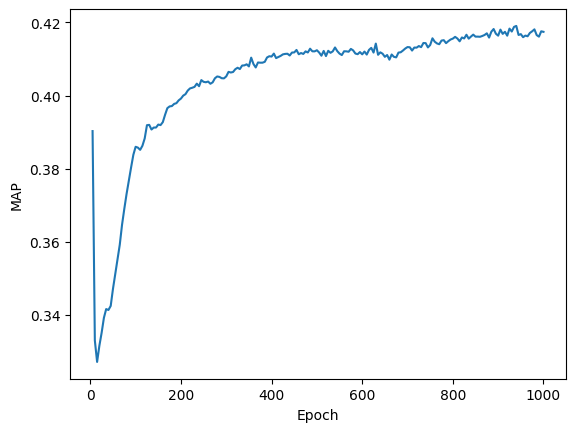

In [60]:
epochs = [m['epoch'] for m in results['val_metrics']]
maps = [m['roc'] for m in results['val_metrics']]  # ou 'ap' selon ce que retourne compute_metrics

plt.plot(epochs, maps)
plt.xlabel('Epoch')
plt.ylabel('MAP')

Text(0.5, 1.0, 'Distribution des normes dans B^n')

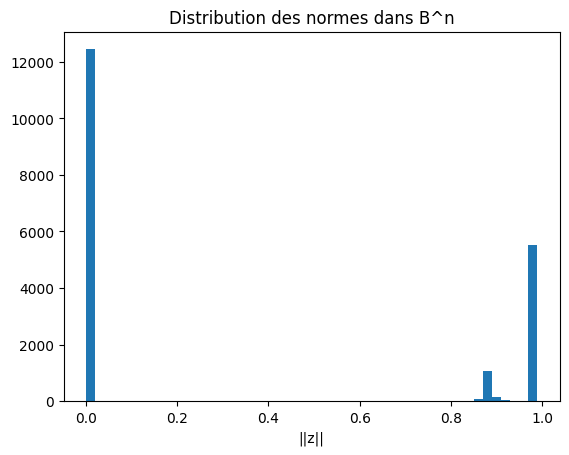

In [61]:
norms = np.linalg.norm(embeddings, axis=1)

plt.hist(norms, bins=50)
plt.xlabel('||z||')
plt.title('Distribution des normes dans B^n')

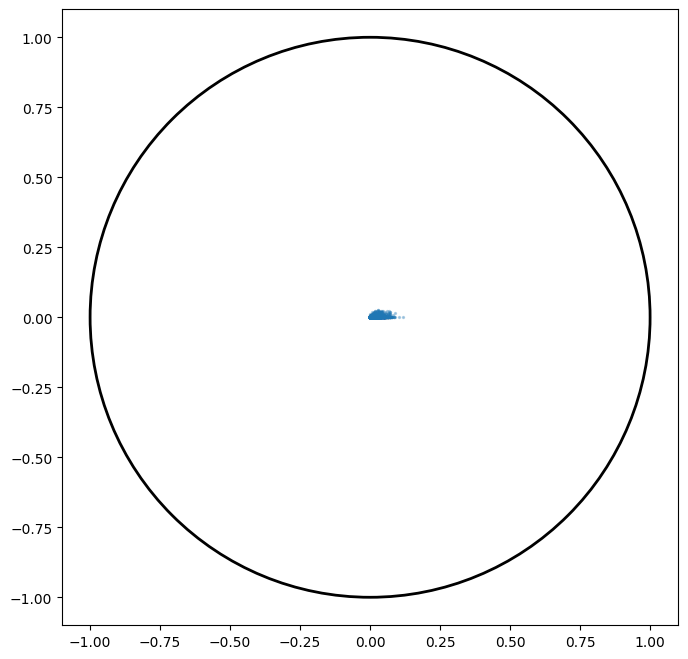

In [ ]:
# Si dim=2
fig, ax = plt.subplots(figsize=(8, 8))
circle = plt.Circle((0, 0), 1, fill=False, color='black', linewidth=2)
ax.add_patch(circle)
ax.scatter(embeddings[:, 0], embeddings[:, 1], s=2, alpha=0.3)
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
ax.set_aspect('equal')